<a href="https://colab.research.google.com/github/aasthajain211/AI-Job-Risk-Analysis-2030/blob/main/AI_Job_Risk_Analysis_2030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [ ]:

# Upload CSV file
from google.colab import files
print("Upload AI_Impact_on_Jobs_2030.csv")
uploaded = files.upload()

# Read CSV into dataframe
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv')

# Check if file loaded correctly
print("✅ File loaded!")
print("Total rows:", len(df))

# See first 5 rows
df.head()

Upload AI_Impact_on_Jobs_2030.csv


Saving AI_Impact_on_Jobs_2030.csv to AI_Impact_on_Jobs_2030.csv
✅ File loaded!
Total rows: 3000


,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [ ]:
# Print all column names
print("Columns in your CSV:")
print(df.columns)

# Check basic info
df.info()

Columns in your CSV:
Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   i

In [ ]:
data = df

data.isna().any()

data.isnull().any()

,0
Employee_ID,False
Job_Title,False
Industry,False
Country,False
Education_Level,False
Years_Experience,False
AI_Replacement_Risk,False
Future_Demand_Score,False
Remote_Work_Possibility,False
Average_Salary_USD,False


In [ ]:
# Check total null values in each column
print("🔍 Null Values Count:")
print(df.isnull().sum())

# Check total duplicate rows
print("\n🔁 Duplicate Rows:", df.duplicated().sum())

# See data types of each column
print("\n📊 Data Types:")
print(df.dtypes)

# Check basic stats to spot weird values like negative
print("\n📈 Basic Statistics:")
df.describe()

🔍 Null Values Count:
Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

🔁 Duplicate Rows: 0

📊 Data Types:
Employee_ID                 object
Job_Title                   object
Industry                    object
Country                     object
Education_Level             object
Years_Experience             int64
AI_Replacement_Risk        float64
Future_Demand_Score        float64
Remote_Work_Possibility     object
Average_Salary_USD           int64


,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,44.773333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,8.926469,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,37.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,45.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,52.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,60.000000,5.000000,5.000000


In [ ]:
# Current USD to INR rate - using 83 as of 2026
# You can change this if rate updates
USD_TO_INR = 83

# Create new column for salary in INR
df['Average_Salary_INR'] = df['Average_Salary_USD'] * USD_TO_INR

# Check if conversion worked
print("✅ New column added: Average_Salary_INR")
print("\n📊 Salary Comparison USD vs INR:")
print(df[['Job_Title', 'Average_Salary_USD', 'Average_Salary_INR']].head())

# Check new min and max in INR
print(f"\n💰 Salary Range in INR:")
print(f"Minimum: ₹{df['Average_Salary_INR'].min():,.0f}")
print(f"Maximum: ₹{df['Average_Salary_INR'].max():,.0f}")
print(f"Average: ₹{df['Average_Salary_INR'].mean():,.0f}")

✅ New column added: Average_Salary_INR

📊 Salary Comparison USD vs INR:
               Job_Title  Average_Salary_USD  Average_Salary_INR
0          Data Engineer              207392            17213536
1     Healthcare Analyst              140785            11685155
2          HR Specialist              124800            10358400
3  Cybersecurity Analyst              199878            16589874
4     Healthcare Analyst              178682            14830606

💰 Salary Range in INR:
Minimum: ₹2,508,343
Maximum: ₹18,259,834
Average: ₹10,511,265


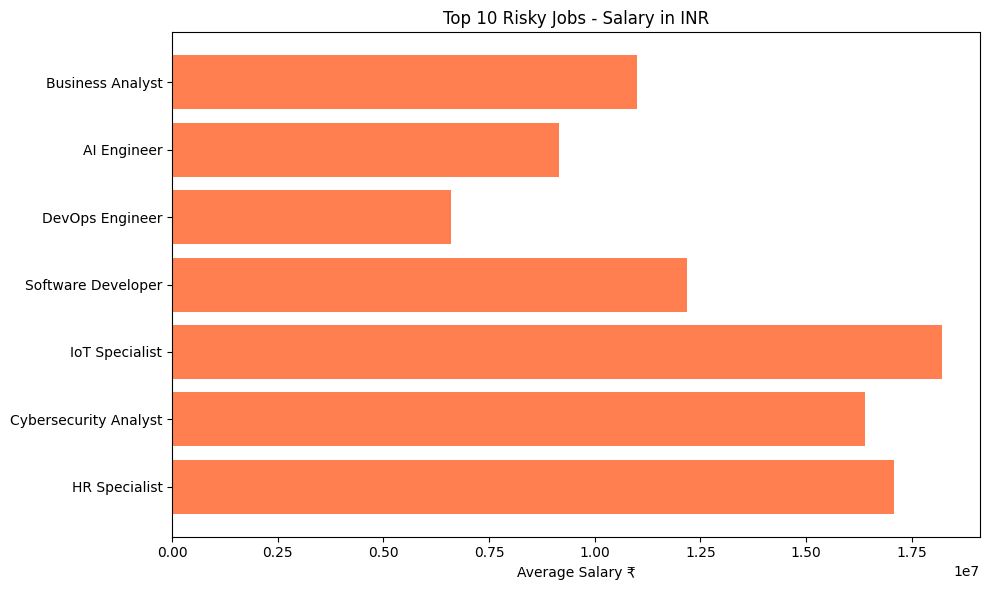

                  Job_Title  AI_Replacement_Risk  Average_Salary_INR
256           HR Specialist                 0.95             5648150
295   Cybersecurity Analyst                 0.95            10948779
752   Cybersecurity Analyst                 0.95            16393745
916          IoT Specialist                 0.95            18207544
939           HR Specialist                 0.95            17075507
953      Software Developer                 0.95            12184068
1019  Cybersecurity Analyst                 0.95            14475034
1272        DevOps Engineer                 0.95             6602899
1486            AI Engineer                 0.95             9160544
1695       Business Analyst                 0.95            11001318


In [ ]:
# Top 10 risky jobs with INR salary
top_risky = df.nlargest(10, 'AI_Replacement_Risk')[['Job_Title', 'AI_Replacement_Risk', 'Average_Salary_INR']]

plt.figure(figsize=(10, 6))
plt.barh(top_risky['Job_Title'], top_risky['Average_Salary_INR'], color='coral')
plt.title('Top 10 Risky Jobs - Salary in INR')
plt.xlabel('Average Salary ₹')
# Format x-axis to show in Lakh
plt.tight_layout()
plt.show()

print(top_risky)

In [ ]:
(df['AI_Replacement_Risk']==0.95).sum()

np.int64(23)

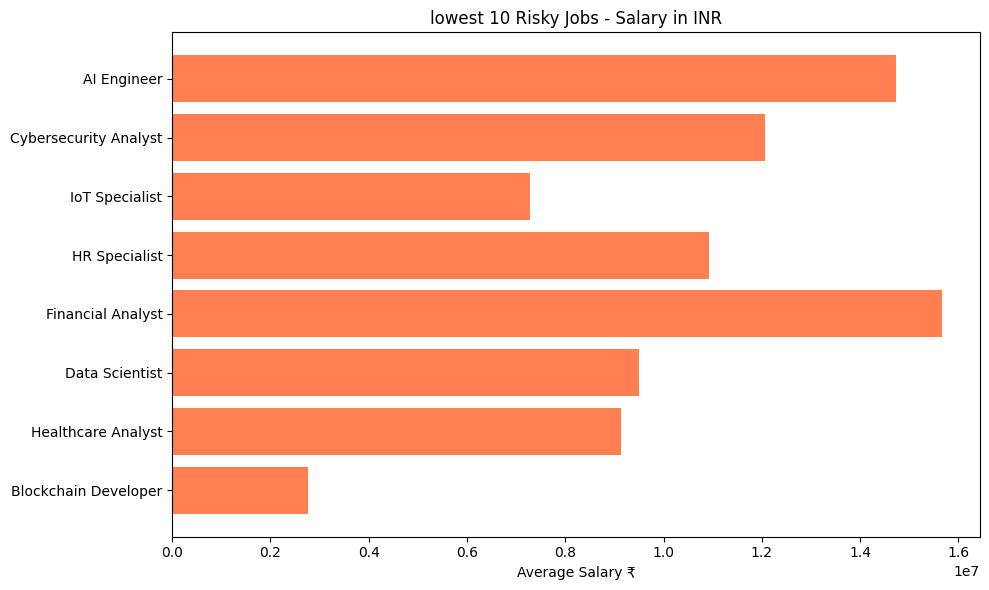

                  Job_Title  AI_Replacement_Risk  Average_Salary_INR
263    Blockchain Developer                 0.05             2755600
344      Healthcare Analyst                 0.05             9138051
430          Data Scientist                 0.05             9500014
463       Financial Analyst                 0.05            15656954
662           HR Specialist                 0.05            10921721
759          IoT Specialist                 0.05             3415201
835   Cybersecurity Analyst                 0.05            12066540
1070            AI Engineer                 0.05            14735820
1301         IoT Specialist                 0.05             7274286
1426     Healthcare Analyst                 0.05             4081691


In [ ]:
# Top 10 lowest risky jobs with INR salary
low_risky = df.nsmallest(10, 'AI_Replacement_Risk')[['Job_Title', 'AI_Replacement_Risk', 'Average_Salary_INR']]

plt.figure(figsize=(10, 6))
plt.barh(low_risky['Job_Title'], low_risky['Average_Salary_INR'], color='coral')
plt.title('lowest 10 Risky Jobs - Salary in INR')
plt.xlabel('Average Salary ₹')
# Format x-axis to show in Lakh
plt.tight_layout()
plt.show()

print(low_risky)

In [ ]:
job_risk = df.groupby('Job_Title')['AI_Replacement_Risk'].mean().sort_values(ascending=False)
print(job_risk)

Job_Title
DevOps Engineer              0.569013
Cloud Architect              0.563876
IoT Specialist               0.526667
Prompt Engineer              0.522237
Teacher                      0.520458
Healthcare Analyst           0.518231
Data Engineer                0.516954
Cybersecurity Analyst        0.510185
Robotics Engineer            0.506728
Blockchain Developer         0.505677
Software Developer           0.496951
HR Specialist                0.492209
Digital Marketer             0.489403
Product Manager              0.486433
Financial Analyst            0.485315
AI Engineer                  0.476452
Business Analyst             0.473475
Machine Learning Engineer    0.472229
Data Scientist               0.470263
UX Designer                  0.460443
Name: AI_Replacement_Risk, dtype: float64


In [ ]:
job_count = df['Job_Title'].value_counts().head(10)
print(job_count)

Job_Title
Software Developer           164
HR Specialist                163
Robotics Engineer            162
Cybersecurity Analyst        162
UX Designer                  158
Machine Learning Engineer    157
Product Manager              157
Blockchain Developer         155
Teacher                      153
DevOps Engineer              152
Name: count, dtype: int64


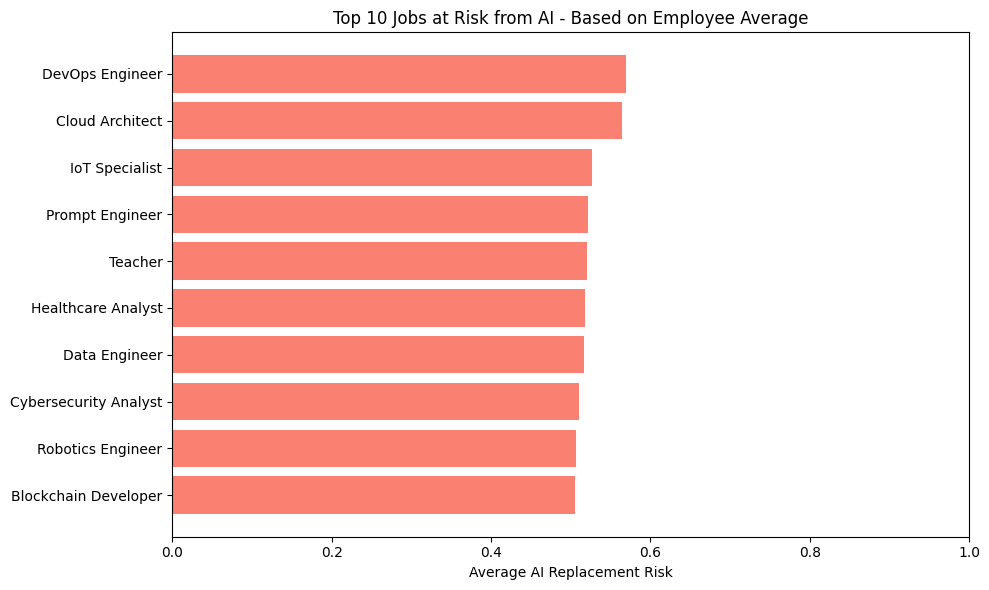

In [ ]:
# Top 10 risky jobs ka average
plt.figure(figsize=(10, 6))
job_risk = df.groupby('Job_Title')['AI_Replacement_Risk'].mean().sort_values(ascending=False).head(10)

plt.barh(job_risk.index, job_risk.values, color='salmon')
plt.title('Top 10 Jobs at Risk from AI - Based on Employee Average')
plt.xlabel('Average AI Replacement Risk')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('1_top_risky_jobs.png', dpi=300, bbox_inches='tight')
plt.show()

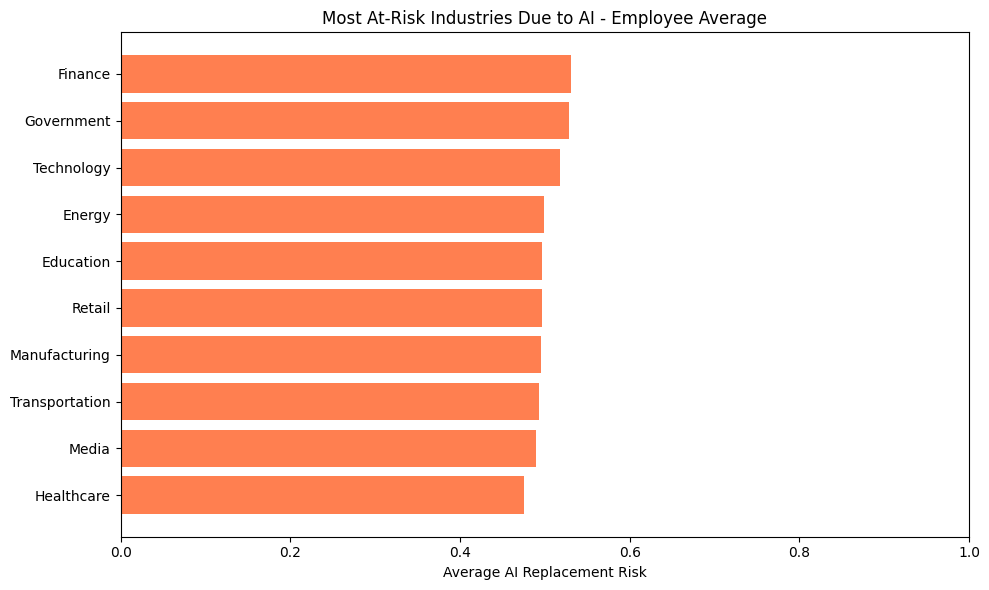

In [ ]:
plt.figure(figsize=(10, 6))
industry_risk = df.groupby('Industry')['AI_Replacement_Risk'].mean().sort_values(ascending=False).head(10)

plt.barh(industry_risk.index, industry_risk.values, color='coral')
plt.title('Most At-Risk Industries Due to AI - Employee Average')
plt.xlabel('Average AI Replacement Risk')
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('2_risky_industries.png', dpi=300, bbox_inches='tight')  # Ye line add kar
plt.show()

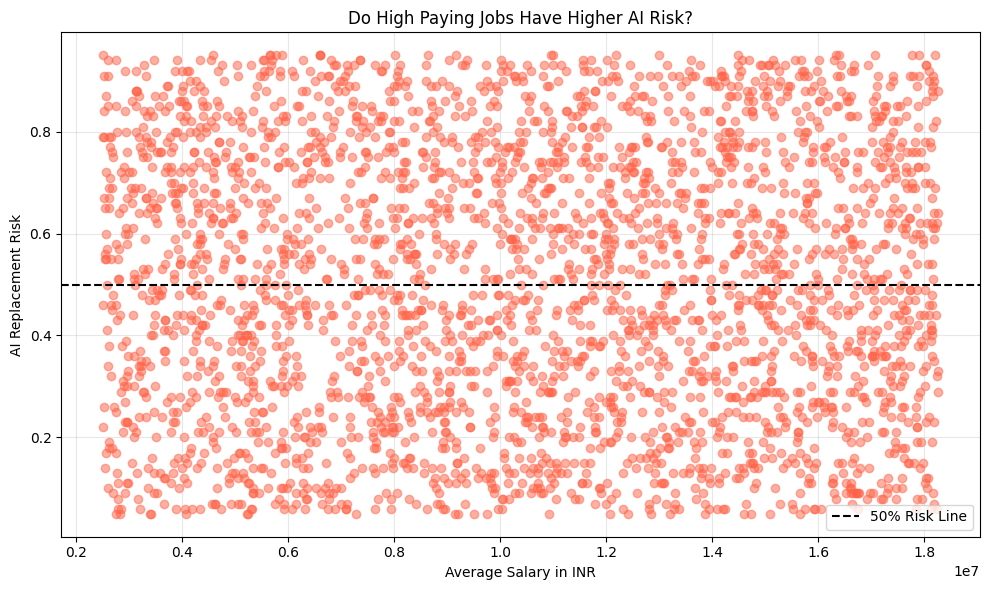

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Average_Salary_INR'], df['AI_Replacement_Risk'], alpha=0.5, color='tomato')
plt.title('Do High Paying Jobs Have Higher AI Risk?')
plt.xlabel('Average Salary in INR')
plt.ylabel('AI Replacement Risk')
plt.axhline(y=0.5, color='black', linestyle='--', label='50% Risk Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('3_salary_vs_risk.png', dpi=300, bbox_inches='tight')  # Ye line add kar
plt.show()